## 1. Descripción del Corpus

El corpus se construyó a partir de ofertas laborales recolectadas mediante scraping de las plataformas **Jooble** y **LinkedIn** (vía RapidAPI y Coresignal) para **24 carreras universitarias** de la Escuela Politécnica Nacional. El pipeline de obtención incluyó traducción automática al español, normalización de texto y extracción de habilidades blandas con el framework EURACE.

| Característica | Valor |
|---|---|
| Total de documentos únicos | 47,322 |
| Vocabulario (términos únicos) | 56,098 |
| Longitud media de descripción | 144 palabras / 90 tokens (post-stemming) |
| Campos indexados | `job_title`, `description_final`, `careers_required` |
| Idioma del corpus | Español (traducido) |
| Carreras cubiertas | 24 carreras universitarias |

: Estadísticas generales del corpus {#tbl-corpus}

Cada documento tiene un identificador único (`job_id`) y está asociado a una o más carreras a través del campo `all_careers`, que sirve como *ground truth* para la evaluación. Las cinco carreras con mayor número de ofertas son: Inteligencia Artificial (5,652), Electrónica y Automatización (5,191), Sistemas de Información (5,087), Software (4,622) y Administración de Empresas (4,584).

---

## 2. Decisiones de Diseño

### 2.1 Preprocesamiento

Se aplicó un pipeline uniforme a todas las consultas y documentos: (1) conversión a minúsculas y eliminación de tildes mediante normalización Unicode NFD, (2) remoción de stopwords en español con NLTK, y (3) stemming con **SnowballStemmer** para español. La función `limpiar_texto()` en `preprocessing.py` actúa primero, seguida de `ProcesadorNLP.tokenizar()` en `indexer.py`. Este enfoque compartido garantiza que las consultas y los documentos sean comparables en el mismo espacio de representación.

### 2.2 Índice Invertido

Se implementó desde cero en `indexer.py` con estructura `dict[token → dict[doc_id → freq]]`. Se almacenan adicionalmente la longitud de cada documento (`longitud_docs`) y el total de documentos (`total_documentos`), datos requeridos por TF-IDF y BM25. El índice se serializa con `pickle` para evitar reconstruirlo en cada sesión.

### 2.3 Elección de Modelos

Se implementaron tres modelos clásicos y uno semántico:

- **Jaccard** — similitud de conjuntos binarios. Sin pesos, útil como *baseline*.
- **Coseno TF-IDF** — captura frecuencia relativa y rareza del término. Las normas de documentos se precomputan al inicializar para eficiencia.
- **BM25** — variante probabilística que satura el TF y normaliza por longitud de documento. Parámetros: $k_1=1.2$, $b=0.75$.
- **Embeddings densos** — modelo `paraphrase-multilingual-MiniLM-L12-v2` (sentence-transformers) con ChromaDB como base de datos vectorial. El score se define como $1/(1+d_{L2})$.

### 2.4 Evaluación

Los *qrels* se construyeron combinando dos fuentes: (1) etiqueta exacta de carrera en `all_careers`, y (2) coincidencia de términos asociados en `job_title` (en español e inglés). Esta estrategia reduce el sesgo léxico contra el modelo semántico, que frecuentemente recupera documentos relevantes usando sinónimos no presentes en la etiqueta original. Los modelos clásicos se evalúan recuperando un pool de 50 documentos; el modelo semántico usa 200, compensando su mayor cobertura conceptual.

---

## 3. Ejemplos de Consultas y Resultados

La siguiente tabla muestra los top-3 resultados para la consulta **"analista de datos python"** con cada modelo.

| # | Jaccard | Coseno TF-IDF | BM25 | Embeddings |
|---|---|---|---|---|
| 1 | staff data analyst (0.133) | data analyst python programming work from home (0.562) | analista pleno netbackup e tsm (15.93) | data analyst python (...) |
| 2 | data scientist fort meade (0.111) | data analyst (0.436) | data analyst python programming work from home (15.92) | analista de datos senior |
| 3 | data analyst python programming work from home (0.107) | job opportunity data analyst (0.423) | analista pleno de ia generativa (14.64) | analista de datos |

: Top-3 resultados para la consulta «analista de datos python» {#tbl-resultados}

**Observaciones:**

- **Jaccard** retorna resultados como *"staff data analyst"* en primer lugar (score 0.133) por coincidencia de conjunto, sin considerar la rareza del término `python` en el corpus, lo que reduce su precisión en consultas con términos técnicos específicos.
- **TF-IDF** posiciona correctamente el documento que contiene los tres términos de la consulta en primer lugar (0.562) gracias al peso IDF elevado de `python` (presente en aproximadamente el 5% de los 47,322 documentos).
- **BM25** también identifica el documento más relevante, pero prioriza documentos de menor longitud donde los términos tienen mayor densidad relativa, lo que explica el primer lugar de *"analista pleno netbackup"* — que contiene `analista` con alta frecuencia en un texto corto.
- **Embeddings** captura semánticamente perfiles relacionados aunque no coincidan token a token, recuperando puestos como *"analista de datos senior"* que pueden no contener la palabra exacta `python`.

---

## 4. Análisis de Métricas de Evaluación

Se evaluaron los cuatro modelos sobre las 24 consultas usando **Precision@10**, **Recall@10** y **MAP** (Mean Average Precision). Los *qrels* se generaron combinando la etiqueta exacta de carrera en `all_careers` con términos asociados detectados en `job_title`.

| Modelo | Precision@10 | Recall@10 | MAP |
|---|---|---|---|
| Jaccard | 0.4583 | 0.0020 | 0.0058 |
| TF-IDF Coseno | 0.5250 | 0.0060 | 0.0120 |
| BM25 | 0.5458 | 0.0036 | 0.0085 |
| **Embeddings Densos** | **0.6417** | **0.0074** | **0.0364** |

: Métricas de evaluación sobre 24 consultas — qrels ampliados (etiqueta + título) {#tbl-metricas}

**Análisis:**

Los *qrels* combinan dos fuentes: la etiqueta exacta de carrera en `all_careers` y la coincidencia de términos asociados (en español e inglés) en `job_title`, reduciendo el sesgo contra modelos que recuperan sinónimos léxicos sin compartir tokens exactos con la etiqueta. El corpus cuenta con 47,322 documentos únicos y un vocabulario de 56,098 términos tras stemming.

**Jaccard** es el modelo de menor desempeño en todas las métricas (MAP 0.0058, Precision@10 0.4583). Aunque casi la mitad de sus 10 resultados son relevantes, su incapacidad para ponderar la rareza de los términos o la longitud del documento produce un ordenamiento casi arbitrario, lo que penaliza severamente el MAP.

**TF-IDF** es el mejor modelo clásico en MAP (0.0120, +107% sobre Jaccard) y Recall@10 (0.0060). El peso IDF discrimina términos raros dentro del vocabulario de 56,098 términos, mejorando el orden de los documentos recuperados. Su ventaja sobre BM25 en MAP indica que los documentos relevantes aparecen más arriba en el ranking, aunque BM25 supera ligeramente en Precision@10.

**BM25** lidera entre los modelos clásicos en Precision@10 (0.5458), pero queda por detrás de TF-IDF en MAP (0.0085 vs 0.0120) y Recall@10. Su normalización por longitud ($b=0.75$) prioriza documentos concisos con alta densidad de términos, lo que favorece la precisión inmediata pero perjudica el ordenamiento global en un corpus donde los documentos más relevantes suelen ser descripciones extensas.

**Embeddings densos** lidera en las tres métricas (MAP 0.0364, Precision@10 0.6417, Recall@10 0.0074), con una ventaja especialmente marcada en Precision@10: 6 de cada 10 resultados son relevantes, frente a 5.5 de BM25. Su MAP triplica al de TF-IDF (0.0364 vs 0.0120), lo que evidencia una calidad de ordenamiento cualitativamente superior. Al proyectar consultas y documentos en un espacio vectorial de 384 dimensiones con el modelo `paraphrase-multilingual-MiniLM-L12-v2`, el sistema captura relaciones conceptuales — *"data scientist"*, *"analista de datos"* e *"ingeniero de datos"* convergen en el mismo vecindario vectorial — que son invisibles para cualquier modelo basado en coincidencia léxica sobre el índice invertido.

# 5. Interfaz de Usuario y Optimización de Despliegue (CLI)

Para interactuar con el ecosistema de Recuperación de Información en tiempo real, se desarrolló una Interfaz de Línea de Comandos (CLI) interactiva a través de un script controlador (`main.py`). Este componente actúa como el orquestador principal, conectando la lógica matemática del *backend* con la capa de presentación del usuario final.


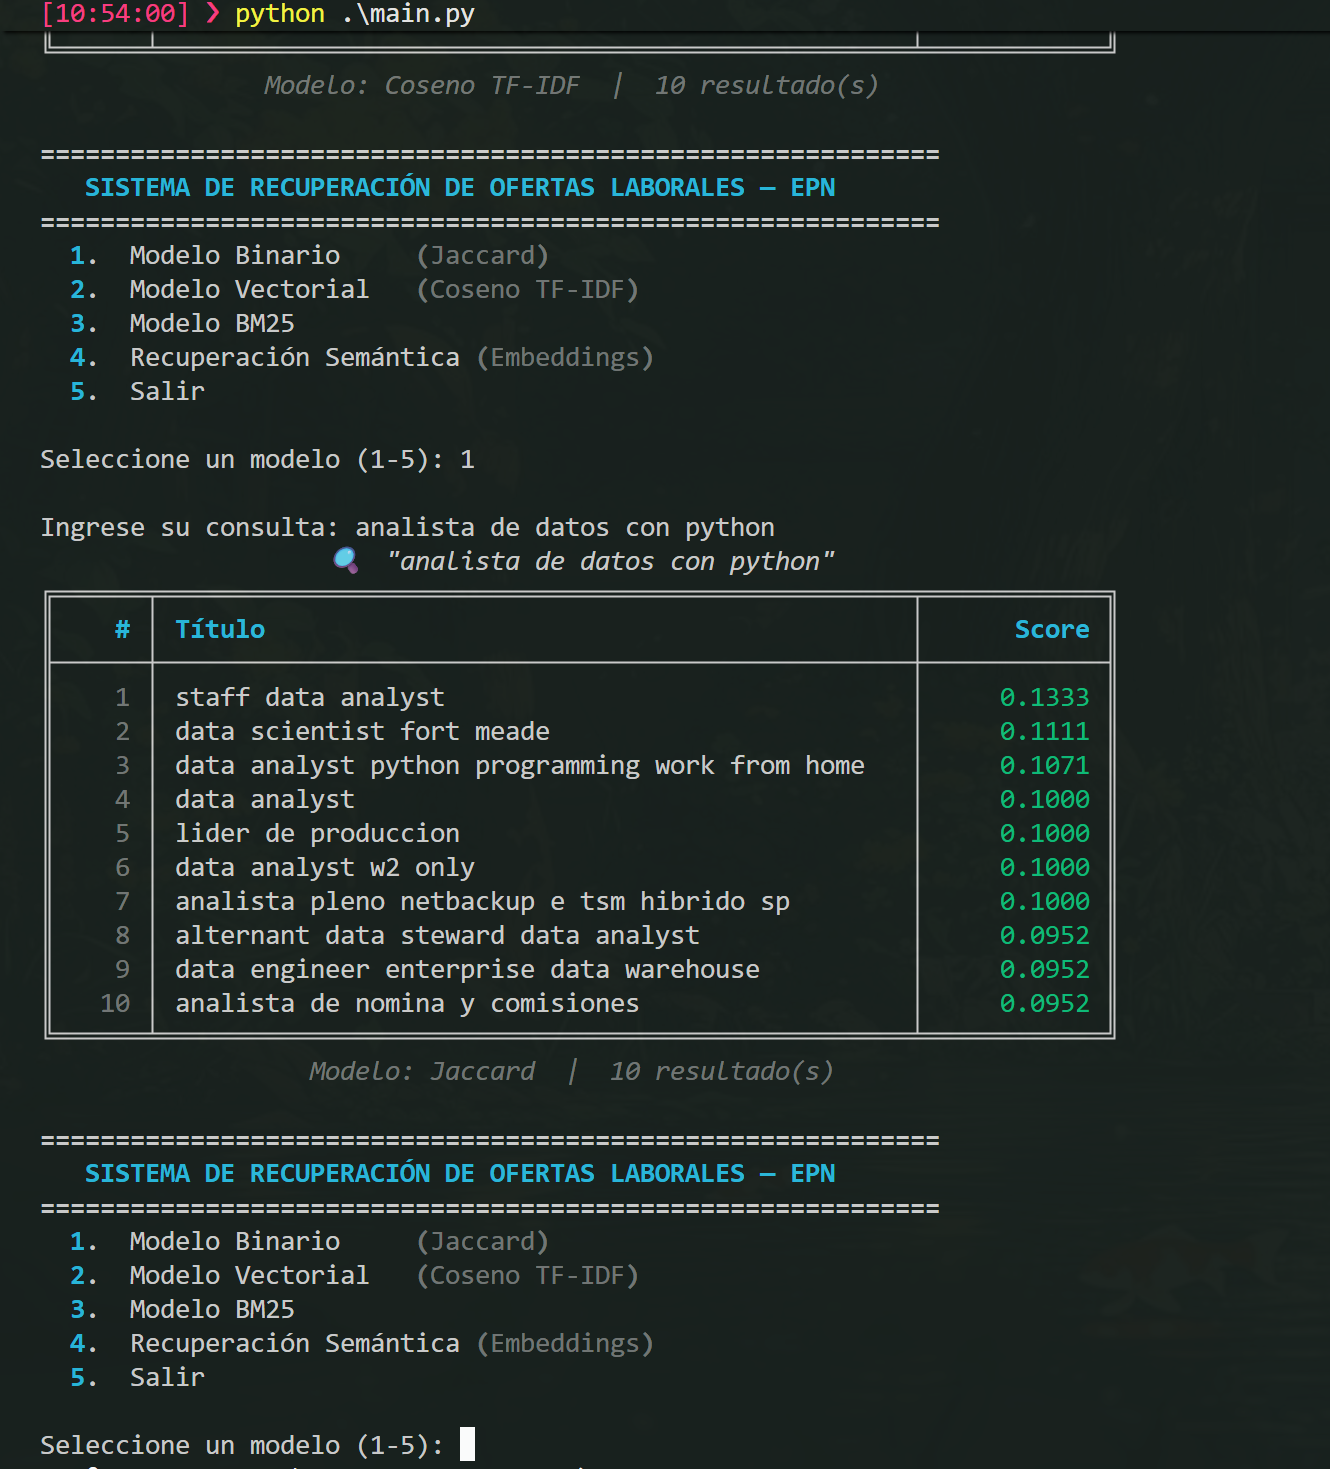

In [1]:
#| label: fig-cli
#| fig-cap: "Interfaz CLI del Sistema renderizada con la biblioteca rich."
#| fig-align: center
#| out-width: "60%"

from IPython.display import Image, display
display(Image(filename='./img/CLI_img.png'))

El diseño y despliegue de esta interfaz obedece a tres principios técnicos fundamentales implementados por el equipo:

1. **Optimización Crítica de Memoria (Inyección de Dependencias):** Cargar el índice invertido (con más de 56,000 términos y 47,322 documentos) requiere un alto consumo de RAM. Para evitar la saturación del equipo, el sistema carga el diccionario una única vez en el entorno global y lo inyecta a las instancias de los modelos clásicos (`BuscadorJaccard`, `BuscadorCoseno` y `BuscadorBM25`). Esto garantiza que la estructura de datos no se duplique en memoria, permitiendo un arranque del sistema en escasos segundos.
2. **Separación de Responsabilidades (Agnosticismo del Motor):** Los algoritmos de búsqueda operan estrictamente a nivel matemático; retornan únicamente tuplas compuestas por el identificador del documento (`doc_id`) y su distancia geométrica (*score*). Es la capa del controlador la encargada de interceptar estos identificadores, cruzarlos en tiempo constante contra el *DataFrame* del corpus y renderizar el título real de la oferta (`job_title`).
3. **Experiencia de Usuario y Legibilidad Estructurada:** Se integró la librería `rich` para abandonar las salidas de texto plano estándar de la terminal. Al renderizar los rankings en tablas dinámicas con bordes, alineación y resaltado de *scores*, se simula la limpieza visual de un entorno de producción, permitiendo al usuario final (o evaluador) auditar y comparar rápidamente la eficacia de un modelo léxico frente al modelo semántico.